In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [224]:
titanic = pd.read_csv("D:\\project\\Github_repository\\titanic-survival-classification\\titanic-survival-classification\\src\\titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [225]:
titanic.shape

(1310, 14)

In [226]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(7), str(7)
memory usage: 210.9 KB


In [227]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [228]:
print(f"unique : {titanic['survived'].unique()}")
print(f"Quantity of null: {titanic['survived'].isna().sum()}")
print(f"index null number: {titanic[titanic['survived'].isna()].index}")
print(f"Quantity of survived: {titanic[titanic['survived'] == 1].value_counts()}")
print(f"Quantity of Drowning: {titanic[titanic['survived'] == 0].value_counts()}")

unique : [ 1.  0. nan]
Quantity of null: 1
index null number: RangeIndex(start=1309, stop=1310, step=1)
Quantity of survived: Series([], Name: count, dtype: int64)
Quantity of Drowning: Series([], Name: count, dtype: int64)


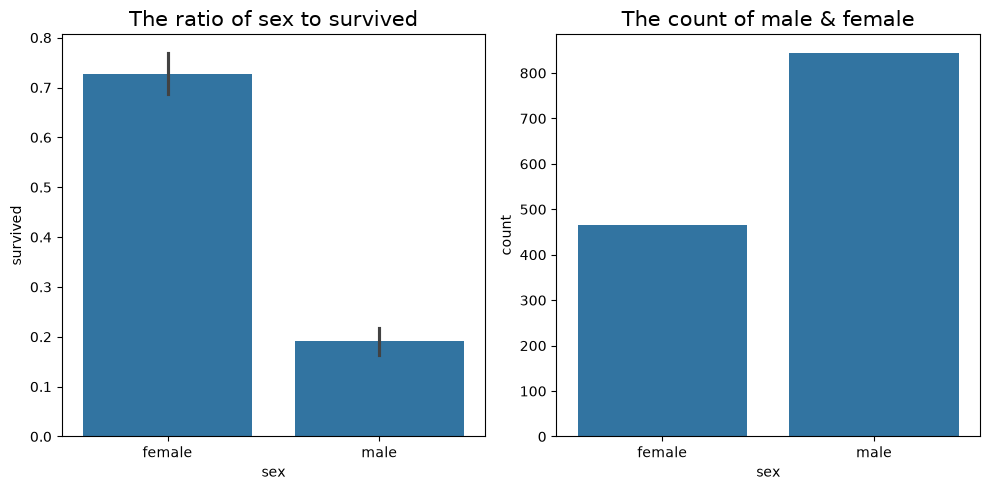

In [229]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='sex', y='survived', ax=axs[0])
axs[0].set_title('The ratio of sex to survived', size=15)

sns.countplot(data=titanic, x='sex', ax=axs[1])
axs[1].set_title('The count of male & female', size=15)

fig.tight_layout()

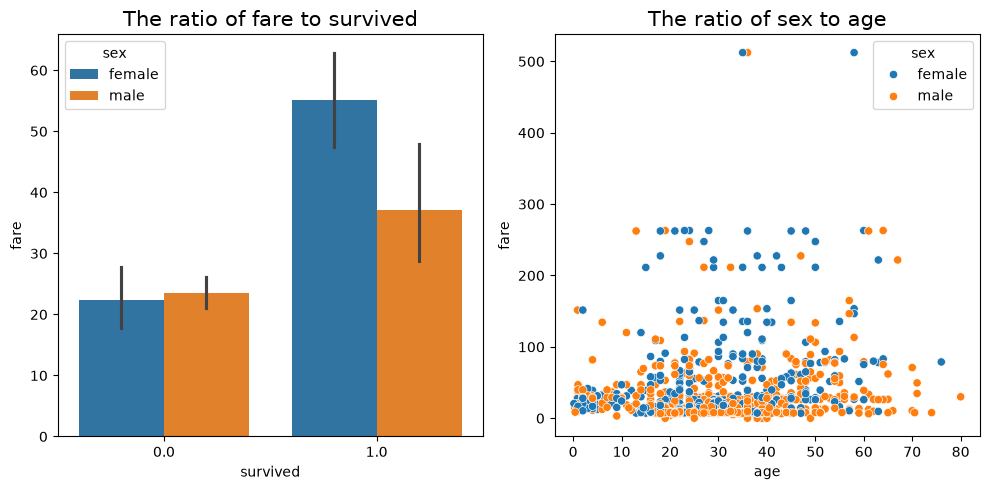

In [230]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [231]:
titanic['ticket'].value_counts()

ticket
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
S.O.C. 14879     7
                ..
2628             1
2647             1
2656             1
2670             1
315082           1
Name: count, Length: 929, dtype: int64

In [232]:
titanic.iloc[1309]

pclass       NaN
survived     NaN
name         NaN
sex          NaN
age          NaN
sibsp        NaN
parch        NaN
ticket       NaN
fare         NaN
cabin        NaN
embarked     NaN
boat         NaN
body         NaN
home.dest    NaN
Name: 1309, dtype: object

In [233]:
titanic = titanic.drop(titanic.index[1309])

In [234]:
titanic.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

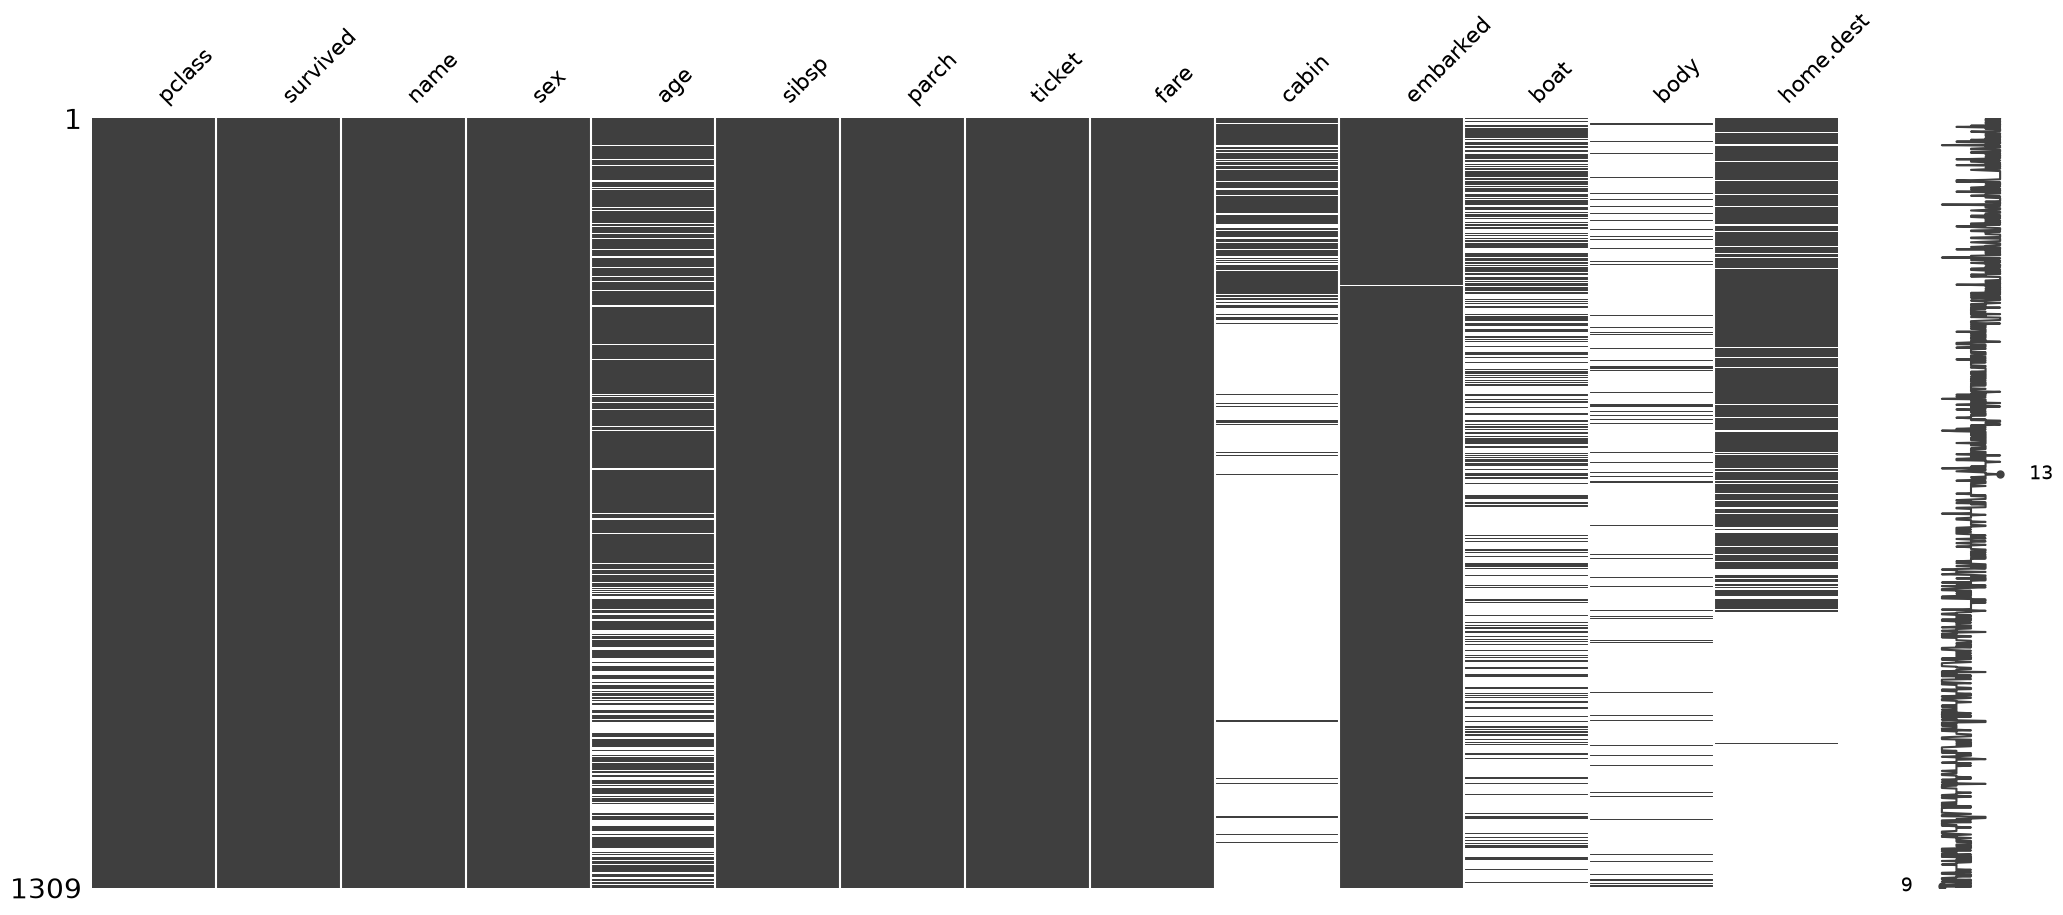

In [235]:
import missingno as msno

msno.matrix(titanic)

In [236]:
titanic['cabin'].value_counts().sum()

np.int64(295)

In [237]:
def drop_missing_columns(df, threshold=50):
    dropped_columns = []

    for col in df.columns:
        if df[col].isnull().mean() * 100 > threshold:
            dropped_columns.append(col)
            df.drop(columns =col, inplace=True)

    return dropped_columns

drop_missing_columns(titanic)

['cabin', 'boat', 'body']

In [238]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,C,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,C,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,C,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,C,NaN


In [239]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
embarked       2
home.dest    564
dtype: int64

In [240]:
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())

In [241]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'].isna().sum()

np.int64(0)

In [242]:
titanic['age']

0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1304    14.5000
1305        NaN
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1309, dtype: float64

In [243]:
titanic['age'] = titanic['age'].interpolate(method='polynomial', order=2)

In [244]:
titanic['age'] = titanic['age'].round()
titanic['age']

0       29.0
1        1.0
2        2.0
3       30.0
4       25.0
        ... 
1304    14.0
1305    18.0
1306    26.0
1307    27.0
1308    29.0
Name: age, Length: 1309, dtype: float64

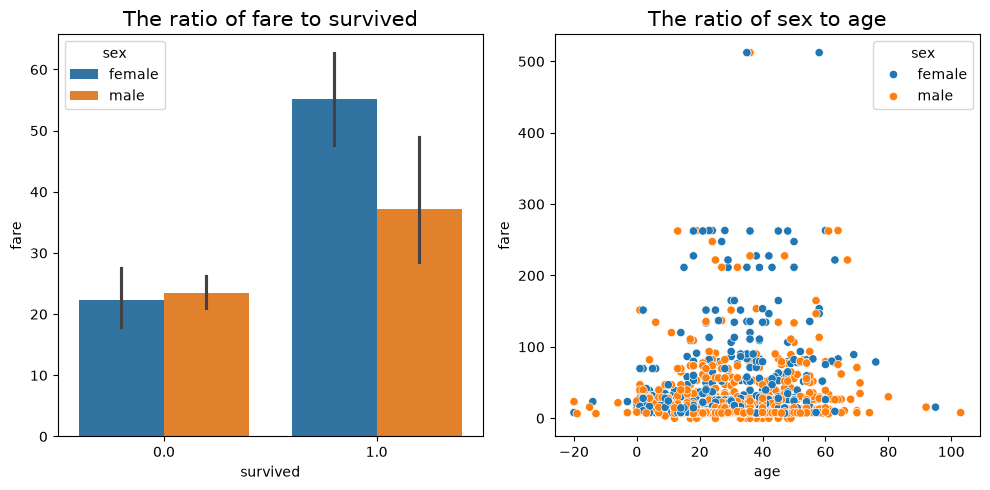

In [245]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [246]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
home.dest    564
dtype: int64

In [247]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1309 non-null   float64
 9   embarked   1309 non-null   str    
 10  home.dest  745 non-null    str    
dtypes: float64(6), str(5)
memory usage: 177.9 KB


In [248]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
